# ftvis — Mode B: Spectrum & Inverse Transform

Part 0~E (`01_intro.ipynb`)에서는 **하나의 ω**를 고정하고 시간 t를 진행시키며 적분이 어떻게 누적되는지 봤다 (Mode A).

여기서는 **시간 적분 구간을 고정하고 ω를 훑는다** (Mode B). 두 새 시각화:

* **Part F — Spectrum**: ω축 + 복소평면 3D. X(jω) 전체 모양이 한 눈에. Mode A의 wound signal 시각화와 *같은 좌표계*.
* **Part G — Inverse Accumulation**: 고정 t에서 ω 화살표를 머리 잇기로 누적해 원본 신호 x(t)에 수렴하는 모습. 푸리에 *역*변환의 직접적 시각화.

In [1]:
import numpy as np
from ftvis import (
    signals, FourierAnalyzer,
    SpectrumPlot, InverseAccumulationPlot,
)

## Part F — Spectrum X(jω) 3D 시각화

ω축 + 복소평면. trail이 ω축을 따라 휘감기는 모양. Mode A의 wound signal과 같은 좌표계라 직관적.

### F1 — Causal exp `e^(-t)·u(t)` (비대칭)

이론값: X(jω) = 1/(1+jω). 비대칭 신호 → trail이 ω축을 따라 *4사분면을 휘감으며* 줄어듦.

* ω = 0:  X = 1
* ω = +1: X = 0.5 − 0.5j
* ω = +∞: X → 0
* 음의 ω 쪽도 대칭(켤레): X(−jω) = X̄(jω). 비대칭 신호의 *위상이 ω의 부호에 따라 반대*.

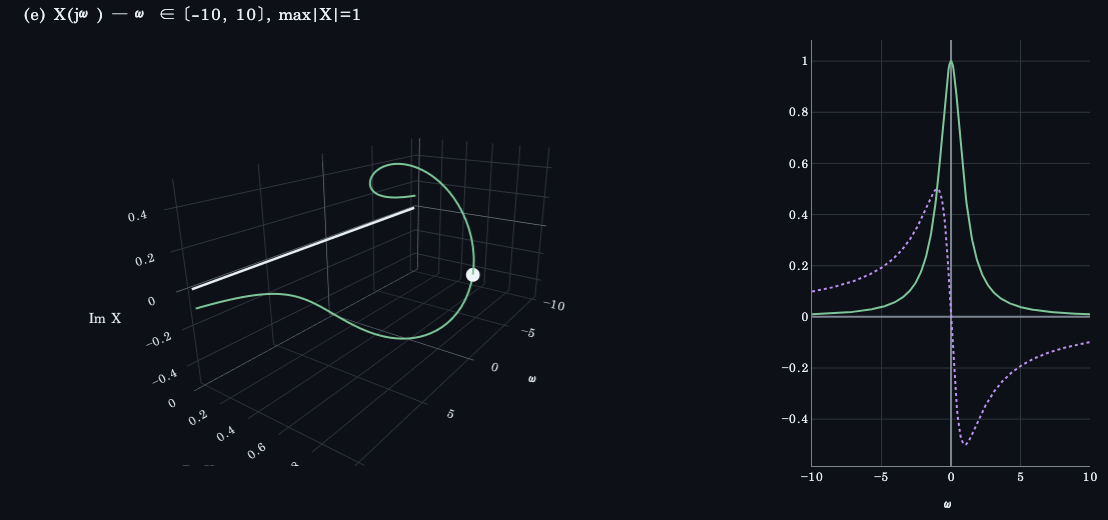

In [2]:
sig = signals.decaying_exp(rate=1.0)
an = FourierAnalyzer(sig, t_min=0.0, t_max=20.0, n_samples=4000)
omegas, X = an.spectrum(omega_min=-10.0, omega_max=10.0, n_omega=400)

p = SpectrumPlot(view='re_im', show_inset=True)
p.show_spectrum(omegas, X)
p.figure.show()

### F2 — Two-sided exp `e^(-|t|)` (짝함수)

X(jω) = 2/(1+ω²). **순수 실수**. trail이 *Re-ω 평면* 안에서만 움직임 — Im 방향으로 떠오르지 않음. 짝함수성이 시각적으로 직접 보임.

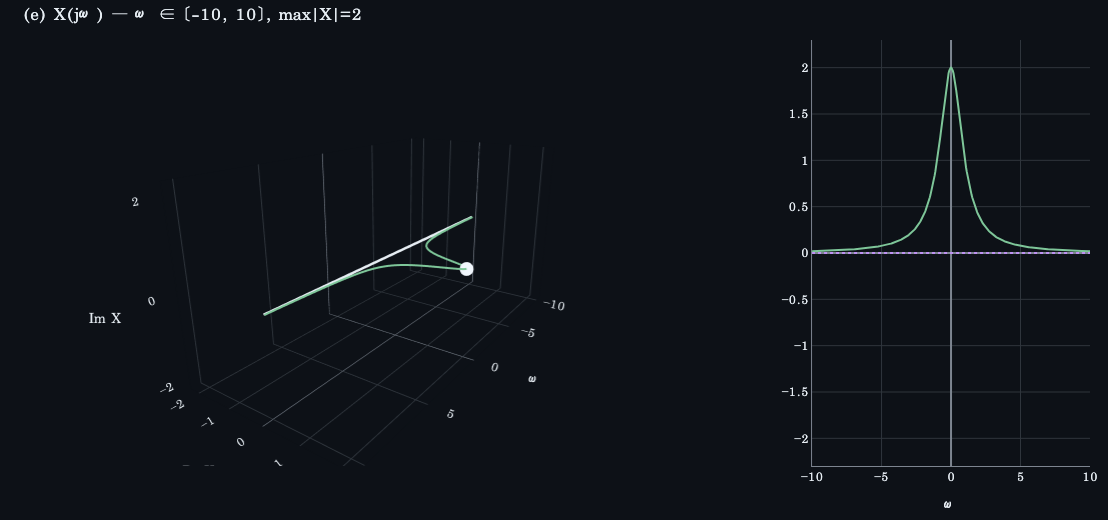

In [3]:
sig = signals.two_sided_exp(rate=1.0)
an = FourierAnalyzer(sig, t_min=-15.0, t_max=15.0, n_samples=4000)
omegas, X = an.spectrum(omega_min=-10.0, omega_max=10.0, n_omega=400)

p = SpectrumPlot(view='re_im', show_inset=True)
p.show_spectrum(omegas, X)
p.figure.show()

### F3 — Gaussian `e^(-t²/2)` (자기쌍대)

X(jω) = √(2π)·e^(-ω²/2). X도 가우시안. 짝함수 → 실수. trail이 ω=0에서 피크.

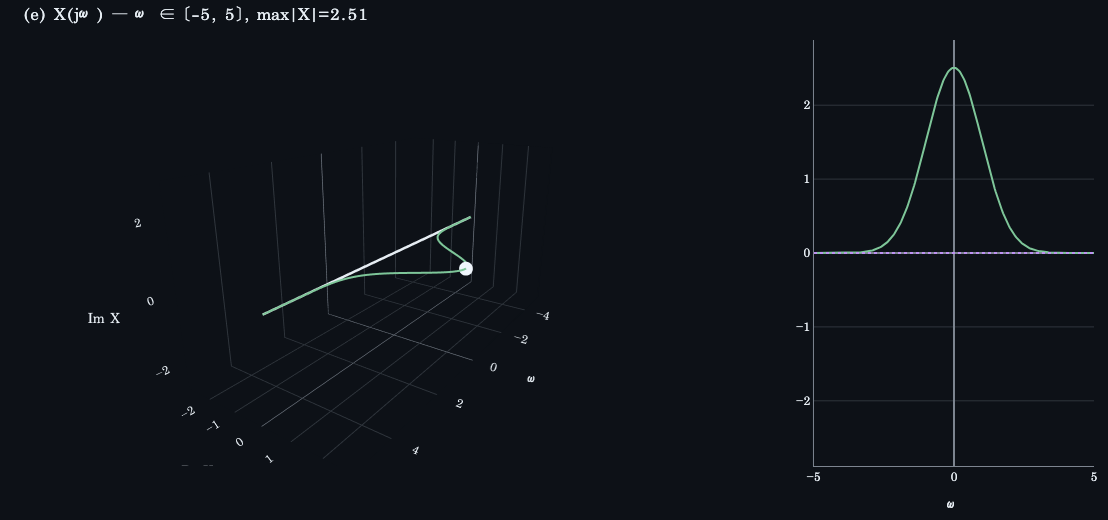

In [4]:
sig = signals.gaussian(sigma=1.0)
an = FourierAnalyzer(sig, t_min=-8.0, t_max=8.0, n_samples=2000)
omegas, X = an.spectrum(omega_min=-5.0, omega_max=5.0, n_omega=300)

p = SpectrumPlot(view='re_im', show_inset=True)
p.show_spectrum(omegas, X)
p.figure.show()

### F4 — 감쇠 정현파 `e^(-t)·cos(2π·t)·u(t)`

X(jω) = (1+jω) / ((1+jω)² + (2π)²). ω = ±2π 근처에 *완만한 두 피크*. RLC 자연 응답의 주파수 특성.

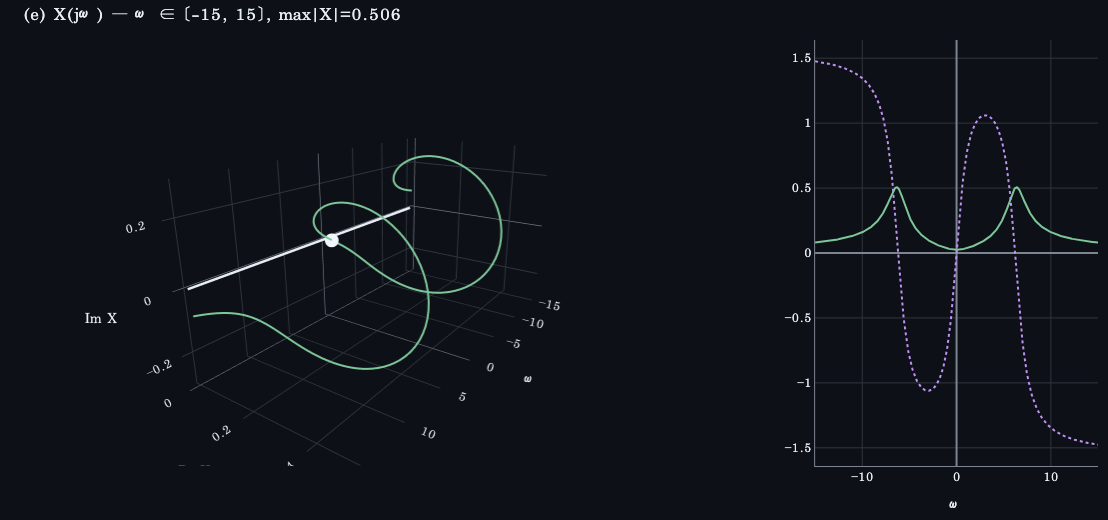

In [5]:
sig = signals.decaying_exp(rate=1.0) * signals.cosine(omega=2*np.pi)
an = FourierAnalyzer(sig, t_min=0.0, t_max=20.0, n_samples=4000)
omegas, X = an.spectrum(omega_min=-15.0, omega_max=15.0, n_omega=600)

p = SpectrumPlot(view='mag_phase', show_inset=True)
p.show_spectrum(omegas, X)
p.figure.show()

## Part G — Inverse Accumulation

**역변환 정의**: $x(t) = \frac{1}{2\pi}\int_{-\infty}^{\infty} X(j\omega)\, e^{j\omega t}\, d\omega$

고정 시점 $t_\text{fix}$에서, ω를 훑으며 각 ω의 기여 화살표 $\frac{1}{2\pi} X(j\omega)\, e^{j\omega t_\text{fix}}\, d\omega$를 *머리 잇기*. 누적 끝점이 $x(t_\text{fix})$에 수렴.

**누적 순서 옵션**:
* `monotonic`: ω_min → ω_max 단조 증가.
* `paired_by_abs`: |ω| 작은 것부터 큰 것 순. ω와 −ω가 인접 누적 → 실수 신호의 *허수부 cancel*이 가장 명료.

### G1 — Gaussian 역변환 @ t_fix=1.0 (monotonic)

x(t) = e^(-t²/2). t=1에서 x=e^(-0.5)≈0.6065 (실수).

accumulated[-1] = 0.6065-0.0000j   target = 0.6065+0.0000j


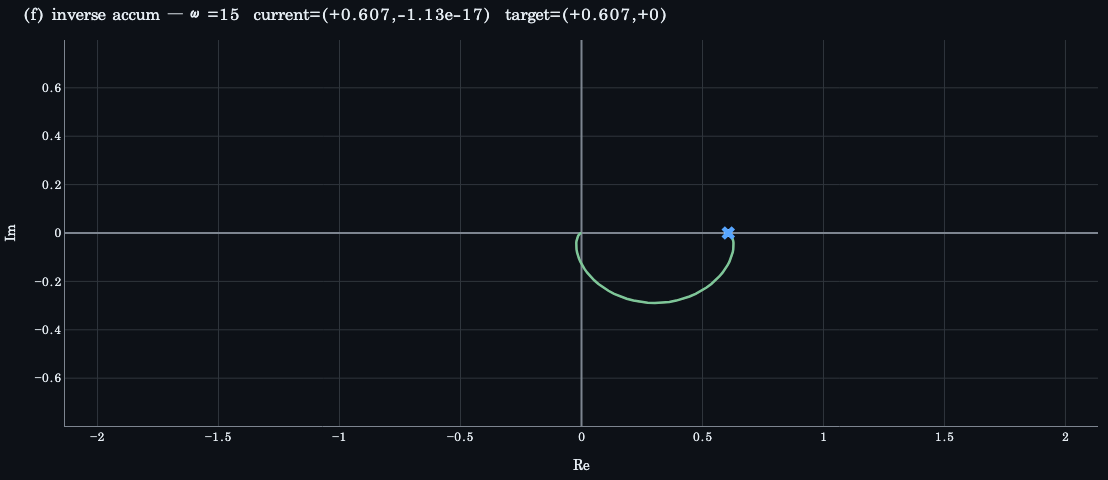

In [6]:
sig = signals.gaussian(sigma=1.0)
an = FourierAnalyzer(sig, t_min=-8.0, t_max=8.0, n_samples=4001)
t_fix = 1.0
omegas, arrows, accum = an.inverse_accumulation(
    t_fix=t_fix, omega_min=-15.0, omega_max=15.0, n_omega=400,
    order='monotonic',
)
target = complex(np.exp(-t_fix**2 / 2))
print(f'accumulated[-1] = {accum[-1]:.4f}   target = {target:.4f}')

p = InverseAccumulationPlot()
p.show_accumulation(omegas, arrows, accum, target=target)
p.figure.show()

### G2 — 같은 신호, paired_by_abs 순서

각 단계에서 ω와 −ω가 짝을 이뤄 더해지므로 *허수부가 매 단계마다 cancel*. trail이 거의 실수축 위에서만 자람. 실수 신호의 X(jω) 켤레 대칭성의 직접적 시연.

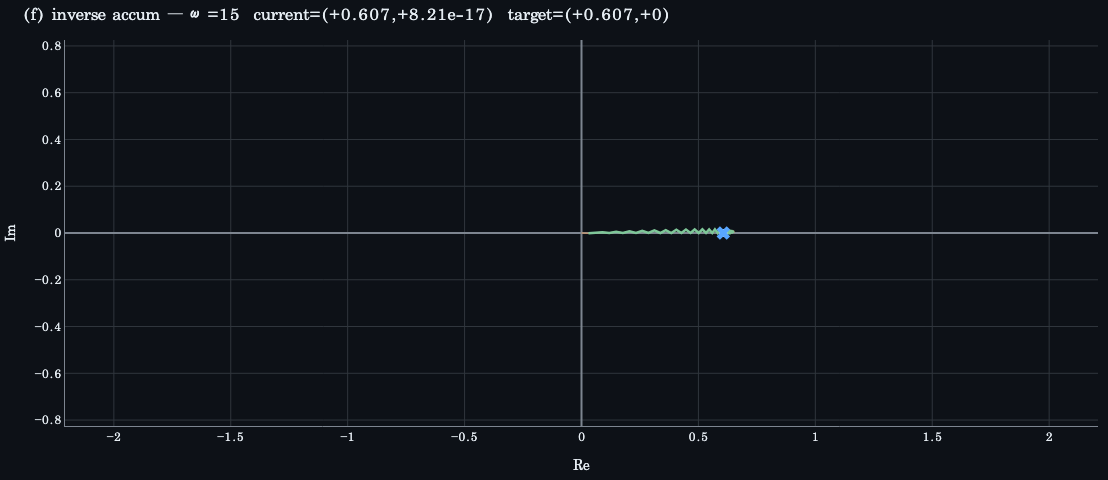

In [7]:
omegas, arrows, accum = an.inverse_accumulation(
    t_fix=t_fix, omega_min=-15.0, omega_max=15.0, n_omega=400,
    order='paired_by_abs',
)
p = InverseAccumulationPlot()
p.show_accumulation(omegas, arrows, accum, target=target)
p.figure.show()

### G3 — 진행 단계별 스냅샷 (causal exp, t_fix=0.5)

x(t) = e^(-t)·u(t). t=0.5에서 x = e^(-0.5) ≈ 0.6065 (실수). monotonic 순서로 25%, 50%, 100% 진행.

frac=0.25:  ω=-15.08  current=0.0161-0.0122j


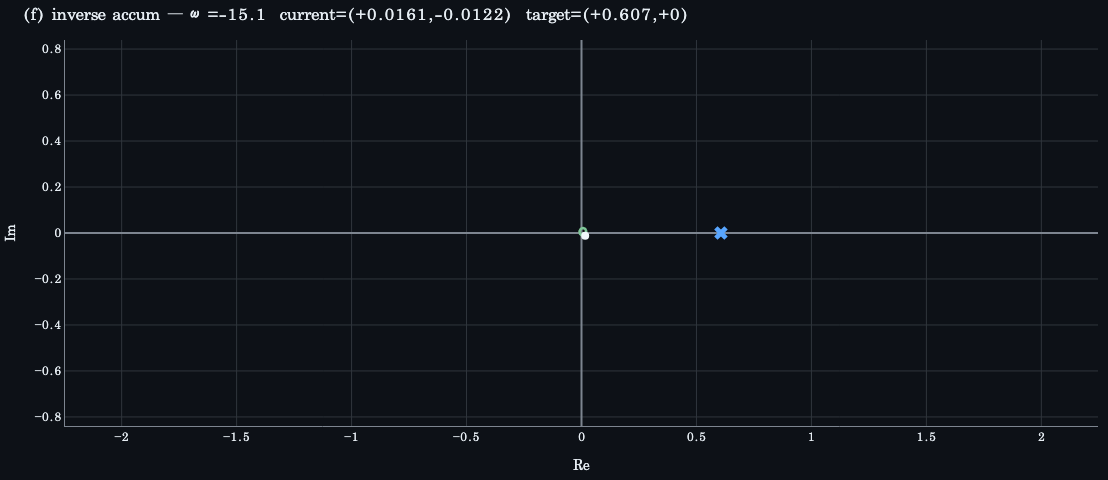

frac=0.5:  ω=-0.05  current=0.3112-0.0369j


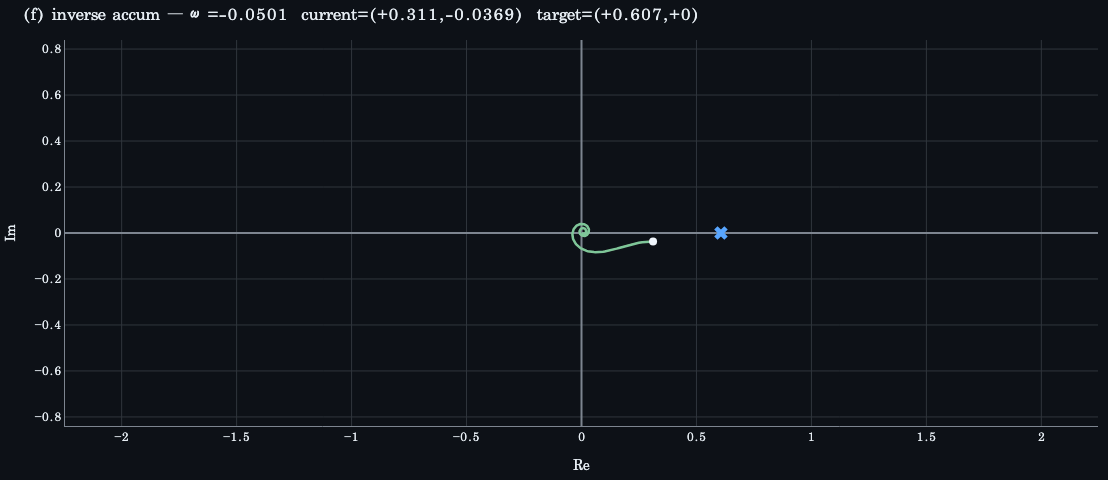

frac=1.0:  ω=+30.00  current=0.6224-0.0000j


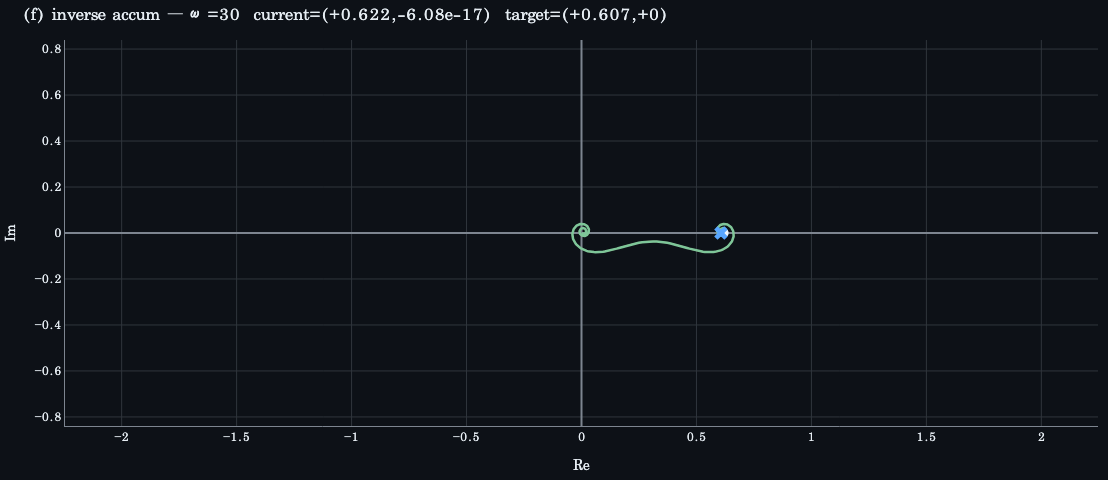

In [8]:
sig = signals.decaying_exp(rate=1.0)
an = FourierAnalyzer(sig, t_min=0.0, t_max=25.0, n_samples=5000)
t_fix = 0.5
omegas, arrows, accum = an.inverse_accumulation(
    t_fix=t_fix, omega_min=-30.0, omega_max=30.0, n_omega=600,
    order='monotonic',
)
target = complex(np.exp(-t_fix))
n = arrows.size
for frac in [0.25, 0.5, 1.0]:
    k = int(frac * (n - 1))
    p = InverseAccumulationPlot()
    p.show_accumulation(omegas, arrows, accum, target=target, progress_index=k)
    print(f'frac={frac}:  ω={omegas[k]:+.2f}  current={accum[k]:.4f}')
    p.figure.show()

### G4 — 다양한 t_fix에서 역변환 결과 비교

Gaussian의 역변환을 t_fix = 0, 0.5, 1.0, 2.0에서 계산해 원본 신호와 비교. 누적합이 *해석적 x(t)와 일치*함을 수치로 확인.

In [9]:
sig = signals.gaussian(sigma=1.0)
an = FourierAnalyzer(sig, t_min=-8.0, t_max=8.0, n_samples=4001)
print(f'{"t_fix":>8}  {"recovered":>22}  {"x(t) analytic":>16}  {"error":>10}')
for t_fix in [0.0, 0.5, 1.0, 2.0, 3.0]:
    _, _, accum = an.inverse_accumulation(
        t_fix=t_fix, omega_min=-30.0, omega_max=30.0, n_omega=2001,
    )
    expected = np.exp(-t_fix**2/2)
    err = abs(accum[-1].real - expected)
    print(f'  {t_fix:6.2f}  ({accum[-1].real:+.4f},{accum[-1].imag:+.4f})    {expected:.4f}    {err:.2e}')

   t_fix               recovered     x(t) analytic       error
    0.00  (+1.0000,+0.0000)    1.0000    3.80e-14
    0.50  (+0.8825,-0.0000)    0.8825    3.30e-14
    1.00  (+0.6065,-0.0000)    0.6065    2.31e-14
    2.00  (+0.1353,-0.0000)    0.1353    5.08e-15
    3.00  (+0.0111,+0.0000)    0.0111    3.82e-16
